In [29]:
from matplotlib import pyplot as plt

from spice_segmenter import log_enable

log_enable("INFO")

In [30]:
from quick_setup import end, start, traj

In [31]:
from spice_segmenter import config

config.solver_step = 60 * 60

In [55]:

from spice_segmenter import (
    Distance,
    Occultation,
    OccultationTypes,
    PhaseAngle,
    SpiceWindow,
)

# define some properties of the trajectory
jupiter_distance = Distance("JUICE", "JUPITER")
io_distance = Distance("JUICE", "IO")

# define the occultation property
io_occultation = Occultation("JUICE", "JUPITER", "IO")

# phase angle
io_phase_angle = PhaseAngle("JUICE", "IO", "SUN")


# compose the properties into a constraint
c = (
    (io_phase_angle > "5 deg")
    & (io_phase_angle < "90 deg")
    & (jupiter_distance < "700000000.0 km")
    & (io_occultation == OccultationTypes.FULL)
)

# solve the constraint within user defined time window
window = SpiceWindow.from_start_end("2023-06-01", "2031-01-01")

out = c.solve(window)
tab = out.to_pandas()


2025-01-29 14:18:31.210 | INFO     | spice_segmenter.constraint_solver.constraint_solver:get_appropriate_solver:767 - Selected solver <class 'spice_segmenter.constraint_solver.constraint_solver.SpiceWindowSolver'> for constraint ((((Phase Angle of IO with respect to SUN as seen from JUICE > 5 degree) & (Phase Angle of IO with respect to SUN as seen from JUICE < 90 degree)) & (Distance of JUPITER from JUICE < 700000000.0 kilometer)) & (Occultation of IO by JUPITER, as seen by JUICE = FULL)), of type <class 'spice_segmenter.constraint.Constraint'>
2025-01-29 14:18:31.210 | INFO     | spice_segmenter.constraint_solver.constraint_solver:get_appropriate_solver:767 - Selected solver <class 'spice_segmenter.constraint_solver.constraint_solver.SpiceWindowSolver'> for constraint ((((Phase Angle of IO with respect to SUN as seen from JUICE > 5 degree) & (Phase Angle of IO with respect to SUN as seen from JUICE < 90 degree)) & (Distance of JUPITER from JUICE < 700000000.0 kilometer)) & (Occultati

In [63]:
print(tab.iloc[::40].to_latex(index=False, sparsify=True))

\begin{tabular}{ll}
\toprule
start & end \\
\midrule
2023-09-01 14:25:48.812000 & 2023-09-01 16:30:53.499000 \\
2023-12-23 18:34:58.652000 & 2023-12-23 20:41:05.128000 \\
2026-12-02 04:59:57.706000 & 2026-12-02 06:11:58.563000 \\
2027-04-01 09:44:43.290000 & 2027-04-01 11:59:35.574000 \\
2027-06-11 03:56:26.837000 & 2027-06-11 06:10:53.373000 \\
2029-04-15 14:27:24.017000 & 2029-04-15 16:32:32.462000 \\
2029-09-21 19:13:55.044000 & 2029-09-21 21:17:20.957000 \\
2029-12-01 13:13:18.458000 & 2029-12-01 15:16:19.535000 \\
2030-02-10 07:12:56.571000 & 2030-02-10 09:15:56.318000 \\
2030-04-22 01:15:48.224000 & 2030-04-22 03:19:10.831000 \\
2030-07-01 19:24:09.554000 & 2030-07-01 21:28:08.220000 \\
2030-09-10 13:38:38.115000 & 2030-09-10 15:43:09.643000 \\
2030-11-20 07:57:59.371000 & 2030-11-20 10:02:47.526000 \\
\bottomrule
\end{tabular}



In [ ]:
txt = """# define some properties of the trajectory
jupiter_distance = Distance("JUICE", "JUPITER")
io_distance = Distance("JUICE", "IO")

# define the occultation property
io_occultation = Occultation("JUICE", "JUPITER", "IO")  

# phase angle
io_phase_angle = PhaseAngle("JUICE", "IO", "SUN")"""


txt = """# compose the properties into a constraint
c = (
    (io_phase_angle > "5 deg")
    & (io_phase_angle < "90 deg")
    & (jupiter_distance < "700000000.0 km")
    & (io_occultation == OccultationTypes.FULL)
)"""

txt = """# solve the constraint within user defined time window
window = SpiceWindow.from_start_end("2023-06-01", "2031-01-01")

out = c.solve(window)
out.to_pandas()"""


txt = """
from spice_segmenter import (
    Distance,
    Occultation,
    OccultationTypes,
    PhaseAngle,
    SpiceWindow,
)

# define some properties of the trajectory
jupiter_distance = Distance("JUICE", "JUPITER")
io_distance = Distance("JUICE", "IO")

# define the occultation property
io_occultation = Occultation("JUICE", "JUPITER", "IO")

# phase angle
io_phase_angle = PhaseAngle("JUICE", "IO", "SUN")


# compose the properties into a constraint
c = (
    (io_phase_angle > "5 deg")
    & (io_phase_angle < "90 deg")
    & (jupiter_distance < "700000000.0 km")
    & (io_occultation == OccultationTypes.FULL)
)

# solve the constraint within user defined time window
window = SpiceWindow.from_start_end("2023-06-01", "2031-01-01")

out = c.solve(window)
out.to_pandas()"""


txt = """# Define the time reference event
REF_EVENT = TimeReference("COEV#3", "2025-03-31T00:00:00")

# Populate the timeline
timeline = Timeline(time_reference=REF_EVENT)

# custom procedures can be added to the timeline
timeline += default_power_on("71 h")  # power on 71 hours after the event
timeline += janus_to_config("30 s", goto="ON", open_com=True)  # go to config mode
timeline.add_command(clear_all_jobs, "1 m", comment="Clar all jobs")

# Example of a single filter imaging action
cfg = FastSinglefilterImages(
    prepro=PreproFlags(compress=True, roi=True),
    binning="NO",
    cmp_idx=compression_index_from_ratio(1),
    roi_start_col=0,
    roi_start_row=0,
    roi_size_col=0,
    roi_size_row=0,
    img_cnt=1,
    exp_time=int(round(1.2 * SEC_TO_TICKS)),
)

# The slews triggers the action
slew = ConstSlewImagingAction_1(dtime=30 * SEC_TO_CSEC)

timeline.add_command(cfg, comment="JAN-02 (RADIOMETRIC MULTI FILTER)")
timeline.add_command(slew)

# Store job
timeline.add_command(StoreJob(1), comment="Store JOB 1")

# Execute job, anc close com
timeline.add_command(StartSci(1), "1 m", comment="Exec images during slew")
timeline.add_command(ComClose(n_csteps=58), "1 m", comment="Close COM")

# Power off JANUS
timeline += janus_off("10 m")

# Export to compatible formats
timeline.to_pandas().to_excel("Example1.xlsx")  # for the user
timeline.expand().to_file("Example1.tcl")  # to be run on REM
timeline.to_file("Example1.csv")  # For SPOT injestion

timeline.to_pandas()  # as a pandas table"""

txt = """# LJC34180 - JANCoverArm - Arm for cover movement
::SEQM::waittimex 10

::TCML::tcsendx LJC34180 

# LJC34181 - JANCoverMv - Open or Close the cover
::SEQM::waittimex 1

::TCML::tcsendx LJC34181 [list LJP34182 OPEN] \
                          [list LJP34183 42]

# LJC35061 - JANClearImgJob - Clear image job current or all
# Clar all jobs
::SEQM::waittimex 60

::TCML::tcsendx LJC35061 [list LJP35003 ALL]

# LJC35077 - JANSingle - Single-filter image with repetition
# JAN-02 (RADIOMETRIC MULTI FILTER)
::SEQM::waittimex 1

::TCML::tcsendx LJC35077 [list LJP35002 48] \
                          [list LJP14801 NO] \
                          [list LJP14802 0] \
                          [list LJP14803 0] \
                          [list LJP14804 0] \
                          [list LJP14805 0] \
                          [list LJP35008 5418] \
                          [list LJP35011 0] \
                          [list LJP35010 1] \
                          [list LJP35028 1] \
                          [list LJP35029 0]

# LJC35071 - JANSlew - Multi filter slew with fixed parameter
::SEQM::waittimex 1

::TCML::tcsendx LJC35071 [list LJP35020 1] \
                          [list LJP35021 3000]

# LJC35060 - JANStoreImgJob - Store image job at position parameter
# Store JOB 1
::SEQM::waittimex 1

::TCML::tcsendx LJC35060 [list LJP35001 1]"""

In [74]:
from pygments.formatters import LatexFormatter
from pygments.lexers import PythonLexer, TclLexer
from pygments.styles import get_style_by_name

style = get_style_by_name("manni")

lex = PythonLexer()

lex = TclLexer()

fmt = LatexFormatter(style=style)

print(fmt.get_style_defs())


\makeatletter
\def\PY@reset{\let\PY@it=\relax \let\PY@bf=\relax%
    \let\PY@ul=\relax \let\PY@tc=\relax%
    \let\PY@bc=\relax \let\PY@ff=\relax}
\def\PY@tok#1{\csname PY@tok@#1\endcsname}
\def\PY@toks#1+{\ifx\relax#1\empty\else%
    \PY@tok{#1}\expandafter\PY@toks\fi}
\def\PY@do#1{\PY@bc{\PY@tc{\PY@ul{%
    \PY@it{\PY@bf{\PY@ff{#1}}}}}}}
\def\PY#1#2{\PY@reset\PY@toks#1+\relax+\PY@do{#2}}

\@namedef{PY@tok@w}{\def\PY@tc##1{\textcolor[rgb]{0.73,0.73,0.73}{##1}}}
\@namedef{PY@tok@c}{\let\PY@it=\textit\def\PY@tc##1{\textcolor[rgb]{0.00,0.60,1.00}{##1}}}
\@namedef{PY@tok@cp}{\def\PY@tc##1{\textcolor[rgb]{0.00,0.60,0.60}{##1}}}
\@namedef{PY@tok@cs}{\let\PY@bf=\textbf\let\PY@it=\textit\def\PY@tc##1{\textcolor[rgb]{0.00,0.60,1.00}{##1}}}
\@namedef{PY@tok@k}{\let\PY@bf=\textbf\def\PY@tc##1{\textcolor[rgb]{0.00,0.40,0.60}{##1}}}
\@namedef{PY@tok@kp}{\def\PY@tc##1{\textcolor[rgb]{0.00,0.40,0.60}{##1}}}
\@namedef{PY@tok@kt}{\let\PY@bf=\textbf\def\PY@tc##1{\textcolor[rgb]{0.00,0.47,0.53}{##1}}}


In [75]:
import pygments

print(pygments.highlight(txt, formatter=fmt, lexer=lex))

\begin{Verbatim}[commandchars=\\\{\}]
\PY{c}{\PYZsh{}}\PY{c}{ Automatically added by janus\PYZus{}commander for running on JANUS SIS}
\PY{n+nb}{lappend}\PY{+w}{ }argl

\PY{o}{:}\PY{o}{:}\PY{n+nv}{SEQM}\PY{o}{:}\PY{o}{:}TS\PYZus{}beg\PY{+w}{ }\PY{n+nv}{\PYZdl{}argv}\PY{+w}{ }\PY{n+nv}{\PYZdl{}argl}

\PY{o}{:}\PY{o}{:}\PY{n+nv}{INST}\PY{o}{:}\PY{o}{:}includeINST

\PY{c}{\PYZsh{}}\PY{c}{ Start of main sequence of commands}

\PY{c}{\PYZsh{}}\PY{c}{ CSC18206 \PYZhy{} StartObcpJanusSwitchOn \PYZhy{} Load and start the OBCP JANUS switch\PYZhy{}on}
\PY{c}{\PYZsh{}}\PY{c}{ JANUS ON}
\PY{c}{\PYZsh{}}\PY{c}{ \PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}\PYZhy{}}
\PY{c}{\PYZsh{}}\PY{c}{ CSC18206 

2025-01-29 14:17:36.719 | WARNING  | spice_segmenter.constraint:__call__:199 - Comparing radian with degree. This is not recommended. Will attempt automatic conversion.
2025-01-29 14:17:36.848 | WARNING  | spice_segmenter.constraint:__call__:199 - Comparing radian with degree. This is not recommended. Will attempt automatic conversion.


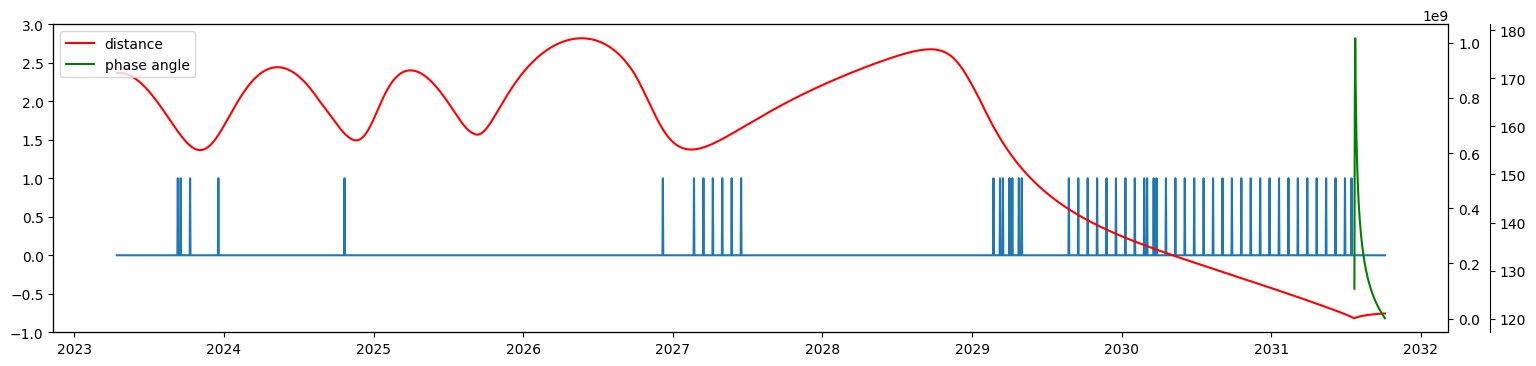

In [54]:
status = c(traj.ets) # compute the status of the constraint over the trajectory

fig, ax = plt.subplots(figsize=(18,4))
ax.plot(traj.utc, status, label="OCC status")

ax.set_ylim(-1, 3)

ax1 = plt.gca()


ax2 = ax1.twinx()

a = ax2.plot(traj.utc, traj.dist, label="distance", color="red")

ax3 = ax1.twinx()
ax3.spines.right.set_position(("axes", 1.03))

b = ax3.plot(traj.utc, traj.phase, label="phase angle", color="green")

plt.legend(a+b, [l.get_label() for l in a+b])

In [5]:
# render the tree of constraints
c.render_tree()

AND
├── AND
│   ├── AND
│   │   ├── (Phase Angle of IO with respect to SUN as seen from JUICE > 5 degree)
│   │   └── (Phase Angle of IO with respect to SUN as seen from JUICE < 90 degree)
│   └── (Distance of JUPITER from JUICE < 700000000.0 kilometer)
└── (Occultation of IO by JUPITER, as seen by JUICE = FULL)


2024-12-11 17:18:11.045 | WARNING  | spice_segmenter.constraint:__call__:196 - Comparing radian with degree. This is not recommended. Will attempt automatic conversion.
2024-12-11 17:18:11.185 | WARNING  | spice_segmenter.constraint:__call__:196 - Comparing radian with degree. This is not recommended. Will attempt automatic conversion.


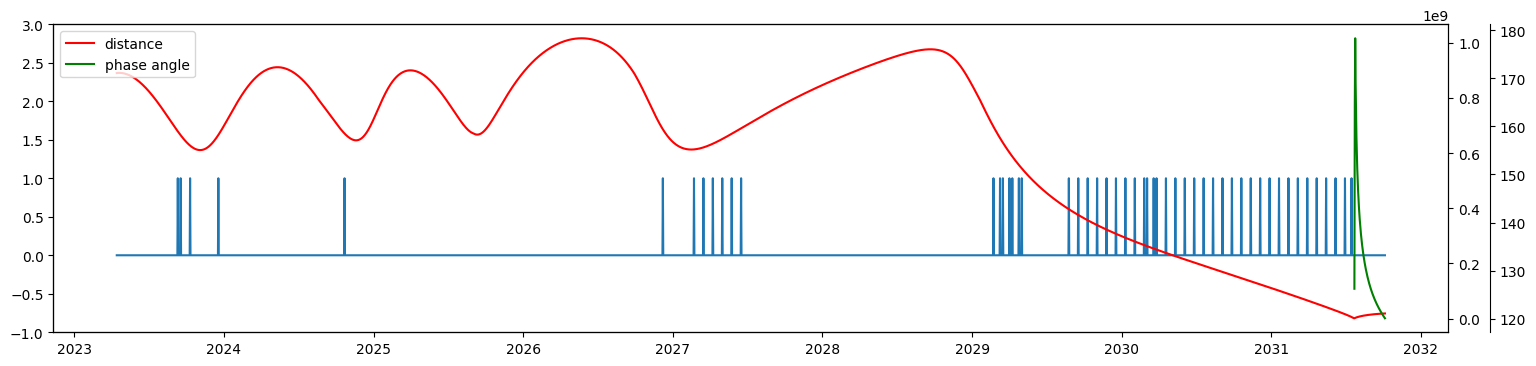

In [6]:
status = c(traj.ets) # compute the status of the constraint over the trajectory

fig, ax = plt.subplots(figsize=(18,4))
ax.plot(traj.utc, status, label="OCC status")

ax.set_ylim(-1, 3)

ax1 = plt.gca()


ax2 = ax1.twinx()

a = ax2.plot(traj.utc, traj.dist, label="distance", color="red")

ax3 = ax1.twinx()
ax3.spines.right.set_position(("axes", 1.03))

b = ax3.plot(traj.utc, traj.phase, label="phase angle", color="green")

plt.legend(a+b, [l.get_label() for l in a+b])


In [7]:
# if we want to get the exact intervals, better use a solver and find the precise start and end

import numpy as np

from spice_segmenter.spice_window import SpiceWindow

shift = np.timedelta64(1, "D")
w = SpiceWindow() # a window from start to end of the trajectory


w.add_interval(start+shift, end-shift) # add the interval from start to end of the trajectory

w

SpiceWindow(2023-04-15T12:42:17.657 to 2031-10-04T01:57:49.500, N: 1)

In [ ]:
result = c.solve(w)
result

SpiceWindow(2023-09-01T14:25:48.811 to 2031-07-21T07:02:03.976, N: 618)

2024-12-11 17:18:14.981 | WARNING  | spice_segmenter.constraint:__call__:196 - Comparing radian with degree. This is not recommended. Will attempt automatic conversion.
2024-12-11 17:18:15.080 | WARNING  | spice_segmenter.constraint:__call__:196 - Comparing radian with degree. This is not recommended. Will attempt automatic conversion.


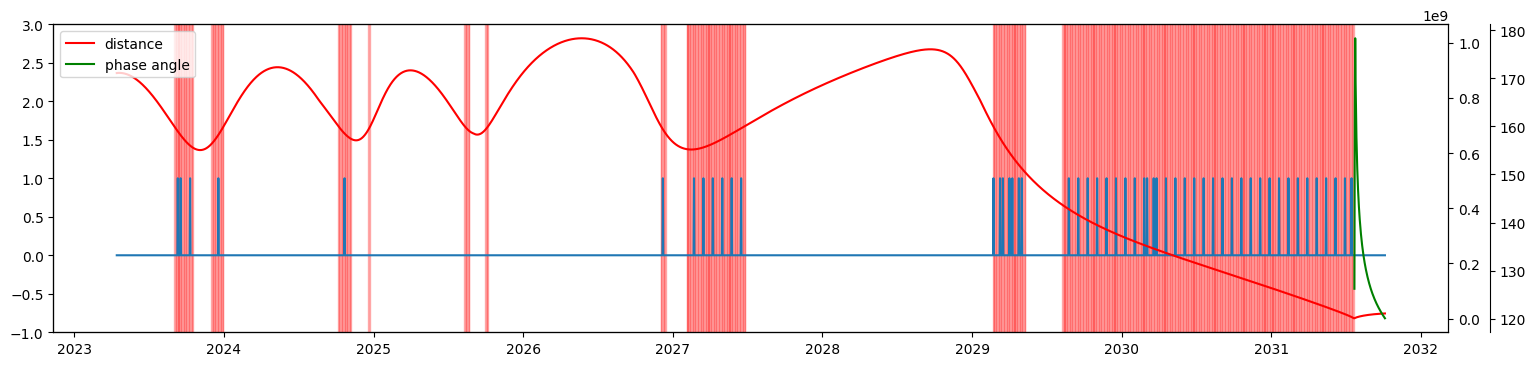

In [9]:
status = c(traj.ets)

fig, ax = plt.subplots(figsize=(18,4))

result.plot(ax=ax, color="red", label="constraint", alpha=0.3) # plot the results

ax.plot(traj.utc, status)

ax.set_ylim(-1, 3)

ax1 = plt.gca()


ax2 = ax1.twinx()

a = ax2.plot(traj.utc, traj.dist, label="distance", color="red")

ax3 = ax1.twinx()
ax3.spines.right.set_position(("axes", 1.03))

b = ax3.plot(traj.utc, traj.phase, label="phase angle", color="green")

plt.legend(a+b, [l.get_label() for l in a+b])

In [ ]:
result.to_datetimerange() # as datetimerange

[2023-09-01T14:25:48 - 2023-09-01T16:30:53,
 2023-09-03T08:53:44 - 2023-09-03T10:58:45,
 2023-09-05T03:21:38 - 2023-09-05T05:26:37,
 2023-09-06T21:49:25 - 2023-09-06T23:54:21,
 2023-09-08T16:17:12 - 2023-09-08T18:22:05,
 2023-09-10T10:44:48 - 2023-09-10T12:49:39,
 2023-09-12T05:12:24 - 2023-09-12T07:17:11,
 2023-09-13T23:39:51 - 2023-09-14T01:44:36,
 2023-09-15T18:07:18 - 2023-09-15T20:12:01,
 2023-09-17T12:34:35 - 2023-09-17T14:39:15,
 2023-09-19T07:01:51 - 2023-09-19T09:06:28,
 2023-09-21T01:28:58 - 2023-09-21T03:33:34,
 2023-09-22T19:56:05 - 2023-09-22T22:00:38,
 2023-09-24T14:23:02 - 2023-09-24T16:27:33,
 2023-09-26T08:49:57 - 2023-09-26T10:54:26,
 2023-09-28T03:16:45 - 2023-09-28T05:21:12,
 2023-09-29T21:43:31 - 2023-09-29T23:47:57,
 2023-10-01T16:10:09 - 2023-10-01T18:14:33,
 2023-10-03T10:36:44 - 2023-10-03T12:41:06,
 2023-10-05T05:03:12 - 2023-10-05T07:07:33,
 2023-10-06T23:29:38 - 2023-10-07T01:33:59,
 2023-10-08T17:55:57 - 2023-10-08T20:00:16,
 2023-10-10T12:22:13 - 2023-10-1

In [ ]:
result.to_pandas() # as pandas dataframe

,start,end
0,2023-09-01 14:25:48.811,2023-09-01 16:30:53.499
1,2023-09-03 08:53:44.016,2023-09-03 10:58:45.989
2,2023-09-05 03:21:38.405,2023-09-05 05:26:37.242
3,2023-09-06 21:49:25.309,2023-09-06 23:54:21.337
4,2023-09-08 16:17:12.040,2023-09-08 18:22:05.028
...,...,...
613,2031-07-13 16:55:08.039,2031-07-13 19:09:25.025
614,2031-07-15 11:47:36.916,2031-07-15 14:04:51.078
615,2031-07-17 06:55:23.553,2031-07-17 09:18:07.924
616,2031-07-19 02:43:26.863,2031-07-19 05:20:11.437


In [12]:
result.to_juice_core_csv("result.csv") # as juice core csv